# Notebook 4 — Hospital × CNN damage overlay

This notebook analyzes whether health facilities are in damaged or intact areas based on CNN predictions. For each facility and assessment date, it:

1.  Identifies nearest footprints (and within `RADIUS_M`).
2.  Scores these footprints using the **trained final CNN**.
3.  Classifies the facility as damaged if scores exceed the CNN's validation threshold.

### Design Notes:

*   **Predictions only:** Uses CNN scores, not UNOSAT ground truth.
*   **Targeted scoring:** Only scores footprints near facilities, avoiding a full city-wide run.
*   **Raw CNN scores:** Uses raw CNN output and its validation threshold, not full pipeline stacker output.
*   **Frame damage rule:** Frame is damaged if `FRAME_FRAC_CUT` of its footprints clear the threshold (mean probability is for description only).
*   **Unmatched facilities:** Facilities beyond `MAX_MATCH_M` are excluded from analysis.
*   **Read-only:** This notebook reads artifacts from `sentinel_sar/experiments/<EXPERIMENT_NAME>/` and writes outputs to the same experiment's `predictions/` and `figures/` folders.

In [67]:
import os, sys, glob, json
import numpy as np
import pandas as pd
import torch
import geopandas as gpd
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import beta as _beta

## 1. Parameters

In [68]:
from google.colab import drive
drive.mount('/content/drive')  # file access

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Add project root and package folder to sys.path
PROJECT_ROOT = "/content/drive/MyDrive/War-Damage-Detection"
SENTINEL_DIR = os.path.join(PROJECT_ROOT, "sentinel_sar")
for path in (PROJECT_ROOT, SENTINEL_DIR):
    if path not in sys.path:
        sys.path.insert(0, path)

# Overlay configuration
CITY            = "Gaza"  # City for analysis
EXPERIMENT_NAME = "exp001_base_cnn_sar"  # Experiment name from notebook 2

# Health facilities data
# Path to the health facilities GeoPackage (from 3a-3c chain)
HEALTH_GPKG     = f"{PROJECT_ROOT}/shared/data/health/gaza_health_facilities.gpkg"
HEALTH_LAYER    = None  # GeoPackage layer name (None = first/only layer)
FACILITY_TYPE_COL = "tier"  # Column for facility type classification
FACILITY_FILTER = None  # Substring filter for FACILITY_TYPE_COL (None = keep all)

# Frame definition parameters
RADIUS_M        = 100.0  # Radius for footprints to form a frame (metres)
MAX_MATCH_M     = 250.0  # Max distance for nearest footprint match (metres)

# Damage classification thresholds
THRESHOLD_SOURCE = "frozen"  # "frozen" (from val metrics) or float (e.g., 0.5)
FRAME_FRAC_CUT  = 0.7  # Fraction of damaged footprints to call a frame damaged

# Mapping and output
MAP_DATE        = None  # Date to map (None = latest assessment date)
OUT_CSV_NAME    = "hospital_cnn_overlay.csv"  # Output CSV filename

### Load necessary files and modules

In [70]:
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

# Import pipeline module
import sentinel_sar.pipeline as pipeline

print(f"pipeline module  : sentinel_sar.pipeline ({pipeline.__file__})")

# Resolve experiments directory
EXP_DIR = pipeline.EXPERIMENTS_DIR
print(f"experiments dir  : {EXP_DIR}")

# Define experiment root
EXPERIMENT_ROOT = os.path.join(EXP_DIR, EXPERIMENT_NAME)
models_dir = os.path.join(EXPERIMENT_ROOT, "models")

# Display health facilities path
print(f"health facilities: {HEALTH_GPKG}")

PROJECT_ROOT = /content/drive/MyDrive/War-Damage-Detection
pipeline module  : sentinel_sar.pipeline (/content/drive/MyDrive/War-Damage-Detection/sentinel_sar/pipeline.py)
experiments dir  : /content/drive/MyDrive/War-Damage-Detection/sentinel_sar/experiments
health facilities: /content/drive/MyDrive/War-Damage-Detection/Data/health/gaza_health_facilities.gpkg


## 2. Load the trained model and its configuration

In [71]:
# Import necessary functions from pipeline module
CITY_REGISTRY    = pipeline.CITY_REGISTRY
experiment_dirs  = pipeline.experiment_dirs
load_run         = pipeline.load_run
load_city        = pipeline.load_city
city_source      = pipeline.city_source
predict_probs    = pipeline.predict_probs
usable_mask      = pipeline.usable_mask
wanted_channels  = pipeline.wanted_channels
strip_dates      = pipeline.strip_dates
parse_split_entry = pipeline.parse_split_entry
split_assignment = pipeline.split_assignment

device = "cuda" if torch.cuda.is_available() else "cpu" # Set compute device

# Resolve experiment and output directories
EXP_ROOT, OUT = experiment_dirs(EXPERIMENT_NAME)
OUT_CSV = os.path.join(OUT["predictions"], OUT_CSV_NAME) # Path for overlay CSV

def read_artifact(path, what, produced_by):
    """Reads a JSON artifact, raises FileNotFoundError if missing."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{what} not found:\n  {path}\n"
            f"It is written by {produced_by}. Run the preflight cell above - "
            "it lists every experiment on Drive and how complete each one is.")
    with open(path) as fh:
        return json.load(fh)

# Load experiment configuration and features
CONFIG = read_artifact(os.path.join(EXP_ROOT, "config.json"), "the experiment config", "notebook 2 at config time (Section 1)")
FEATURES = CONFIG["features"]
CHANNELS = wanted_channels(FEATURES)

# Load final model selection details
SEL = read_artifact(os.path.join(OUT["metrics"], "final_selection.json"), "the frozen final selection", "notebook 2 at model selection, after validation")
FINAL_TAG     = SEL["run"]
FINAL_VARIANT = SEL["variant"]

# Load the trained CNN model and its normalization statistics
run = load_run(OUT["models"], FINAL_TAG, device=device)
model, mu, sd = run["model"], run["mu"], run["sd"]
if run["channel_names"] != CHANNELS:
    raise RuntimeError(f"checkpoint channels {run['channel_names']} != "
                       f"config channels {CHANNELS}")

# Determine damaged classification threshold
if THRESHOLD_SOURCE == "frozen":
    ms_path = os.path.join(OUT["metrics"], "validation_model_selection.csv")
    if not os.path.exists(ms_path):
        raise FileNotFoundError(
            f"the validation candidate table is missing:\n  {ms_path}\n"
            "It is written by notebook 2 at model selection. Either finish "
            "that run, or set THRESHOLD_SOURCE to a float in Section 1 to "
            "cut the CNN score at a threshold you choose yourself.")
    ms = pd.read_csv(ms_path)
    row = ms[(ms["run"] == FINAL_TAG) & (ms["variant"] == "cnn")]
    if not len(row):
        row = ms[ms["variant"] == "cnn"]
    if not len(row):
        raise RuntimeError(
            f"{ms_path} has no 'cnn' variant row, so there is no raw-CNN "
            "threshold to freeze on. Set THRESHOLD_SOURCE to a float in "
            f"Section 1. Variants present: {sorted(ms['variant'].unique())}")
    # Use mean of val_thresholds if multiple exist, otherwise the single value
    thr_vals = row["val_threshold"].astype(float).to_numpy()
    if np.allclose(thr_vals, thr_vals[0]):
        THRESHOLD = float(thr_vals[0])
        thr_note  = f"frozen CNN validation threshold ({FINAL_TAG})"
    else:
        THRESHOLD = float(thr_vals.mean())
        thr_note  = (f"frozen CNN validation threshold ({FINAL_TAG}), MEAN of "
                     f"{len(thr_vals)} per-date candidates "
                     f"[{thr_vals.min():.3f}, {thr_vals.max():.3f}]"
            )
        print(f"NOTE: {len(thr_vals)} differing val_threshold rows for this "
              f"run/variant; using their mean. Report this if the spread "
              f"mattered: {np.round(thr_vals, 3).tolist()}")
else:
    THRESHOLD = float(THRESHOLD_SOURCE) # Use user-defined threshold
    thr_note  = "user-set"

# Resolve assessment dates and map date
DATES = list(CITY_REGISTRY[CITY]["label_dates"])
MAP_DATE = MAP_DATE or DATES[-1]

# Print summary of loaded model and settings
print(f"experiment       : {EXPERIMENT_NAME}")
print(f"final pipeline   : {FINAL_TAG} / {FINAL_VARIANT}")
if FINAL_VARIANT != "cnn":
    print("  NOTE: overlay uses the RAW CNN score, not the full selected "
          f"pipeline ({FINAL_VARIANT}).")
print(f"channels         : {CHANNELS}")
print(f"damaged cut    : {THRESHOLD:.3f}  ({thr_note})")
print(f"assessment dates : {DATES}")
print(f"overlay CSV      : {OUT_CSV}")
print(f"device           : {device}")

experiment       : exp001_base_cnn_sar
final pipeline   : hpo / xgb_spatial_temporal
  NOTE: overlay uses the RAW CNN score, not the full selected pipeline (xgb_spatial_temporal).
channels         : ['s1_pre_VV', 's1_pre_VH', 's1_post_VV', 's1_post_VH']
damaged cut    : 0.196  (frozen CNN validation threshold (hpo))
assessment dates : ['20240503', '20240706', '20240906']
overlay CSV      : /content/drive/MyDrive/War-Damage-Detection/sentinel_sar/experiments/exp001_base_cnn_sar/predictions/hospital_cnn_overlay.csv
device           : cpu


## 3. Load city data and index its footprints

In [72]:
d = load_city(CITY) # Load city data
n_build = len(d["lat"]) # Number of footprints
print(f"{CITY}: {n_build:,} footprints")

# Project footprint centroids to local UTM for accurate distances
build_pts = gpd.GeoDataFrame(geometry=gpd.points_from_xy(d["lon"], d["lat"]), crs="EPSG:4326")
UTM = build_pts.estimate_utm_crs() # Estimate UTM CRS
build_m = build_pts.to_crs(UTM) # Project to UTM
build_xy = np.c_[build_m.geometry.x.values, build_m.geometry.y.values] # Extract XY coordinates
tree = cKDTree(build_xy) # Create k-d tree for spatial queries

# Split bands from experiment config
# Get band fractions from CONFIG["split"] (config.json)
BANDS   = strip_dates({k: v for k, v in CONFIG["split"].items() if k != "holdout"})
fp_band = split_assignment(np.asarray(d["lat"]), CITY, BANDS) # Assign footprints to bands

# Process city-specific band ranges
_city_bands = set()
for part in ("train", "stack", "val", "test"):
    for entry in BANDS.get(part, []):
        c_, lo, hi = parse_split_entry(entry)
        if c_ == CITY:
            _city_bands.add((float(lo), float(hi), part))
_city_bands = sorted(_city_bands)

lat_sorted = np.sort(d["lat"])
def band_of(lat_values):
    """Assigns facilities to split bands based on building-latitude ECDF."""
    q = np.searchsorted(lat_sorted, np.asarray(lat_values)) / n_build
    out = np.full(len(q), "unused", dtype=object)
    for lo, hi, part in _city_bands:
        out[(q >= lo) & ((q < hi) | (hi >= 1.0))] = part
    return out

# Print footprint counts per band
for part in ("train", "stack", "val", "test", "unused"):
    n = int((fp_band == part).sum())
    if n:
        print(f"  {part:>6}: {n:,} footprints ({n / n_build * 100:.0f}%)")

sys_index = d["table"]["system:index"].to_numpy() # Get system:index for footprints
print(f"projected to {UTM.to_string()}")

Gaza: 203,947 footprints
   train: 91,776 footprints (45%)
   stack: 22,434 footprints (11%)
     val: 22,434 footprints (11%)
    test: 67,303 footprints (33%)
projected to EPSG:32636


## 4. Load health facilities

In [73]:
if not os.path.exists(HEALTH_GPKG):
    # If GeoPackage not found, list candidates under PROJECT_ROOT
    hits = glob.glob(f"{PROJECT_ROOT}/**/*health*.gpkg", recursive=True)
    raise FileNotFoundError(
        f"{HEALTH_GPKG} not found. Candidates under PROJECT_ROOT:\n  " +
        ("\n  ".join(hits) if hits else "(none - check the path)"))

fac = gpd.read_file(HEALTH_GPKG, layer=HEALTH_LAYER) # Load health facilities GeoDataFrame
print(f"loaded {len(fac)} facilities; columns: {list(fac.columns)}")

def pick(cols, *keys):
    """Heuristically picks a column name based on keywords."""
    for k in keys:
        for c in cols:
            if k in c.lower():
                return c
    return None

# Identify name and type columns for facilities
NAME_COL = pick(fac.columns, "name", "facility", "label")
TYPE_COL = (FACILITY_TYPE_COL if FACILITY_TYPE_COL in fac.columns else
            pick(fac.columns, "tier", "type", "category", "amenity", "func",
                 "level", "kind", "class"))
if FACILITY_TYPE_COL and FACILITY_TYPE_COL not in fac.columns:
    print(f"FACILITY_TYPE_COL {FACILITY_TYPE_COL!r} is not a column; "
          f"guessed {TYPE_COL!r} instead")
print(f"name column: {NAME_COL!r}   type column: {TYPE_COL!r}")

# Display value counts for categorical columns for verification
for col in [c for c in ("tier", "subtype", "level", "service", "owner")
            if c in fac.columns]:
    counts = fac[col].astype(str).value_counts()
    shown = "; ".join(f"{v} ({n})" for v, n in counts.head(8).items())
    more = f"; ... {len(counts) - 8} more" if len(counts) > 8 else ""
    print(f"  {col:9s}: {shown}{more}")

# Apply facility filter if specified
if FACILITY_FILTER and TYPE_COL is not None:
    mask = fac[TYPE_COL].astype(str).str.contains(FACILITY_FILTER, case=False, na=False)
    print(f"\nfilter {TYPE_COL} ~ '{FACILITY_FILTER}': {mask.sum()} of {len(fac)} kept")
    if mask.any():
        fac = fac[mask].copy()
    else:
        raise ValueError(
            f"FACILITY_FILTER {FACILITY_FILTER!r} matched no value in "
            f"{TYPE_COL!r}. Pick a value from the counts printed above, or "
            "set FACILITY_FILTER = None in Section 1 to analyse every "
            "facility deliberately.")
elif FACILITY_FILTER:
    raise ValueError(
        f"no type-like column found among {list(fac.columns)}. Set "
        "FACILITY_TYPE_COL in Section 1, or FACILITY_FILTER = None.")

# Reproject facilities to UTM and extract relevant data
fac = fac.to_crs(UTM).reset_index(drop=True) # Reproject to UTM
fac_xy = np.c_[fac.geometry.x.values, fac.geometry.y.values] # XY coordinates
fac_id = fac.index.to_numpy() # Unique facility IDs
fac_name = (fac[NAME_COL].astype(str).values if NAME_COL
            else np.array([f"facility_{i}" for i in range(len(fac))])) # Facility names
print(f"{len(fac)} facilities carried forward")

loaded 101 facilities; columns: ['facility_id', 'source_id', 'name', 'tier', 'subtype', 'service', 'level', 'owner', 'governorate', 'geometry']
name column: 'name'   type column: 'tier'
  tier     : primary (73); hospital (28)
  subtype  : Clinic | عيادة (50); Clinic (22); General | عام (12); Specialization | اختصاص (11); Maternity | ولادة (4); Rehabilitation | تأهيل (1); Combined Clinic | عيادة مشتركة (1)
  level    : nan (50); 3.0 (22); 2.0 (19); 4.0 (10)
  service  : None (22); General | عامة (17); General+Specialized+Mother & Child Health | عامة+اختصاص+رعاية الام والطفل (14); General | عام (12); Specialization | اختصاص (11); General+Mother & Child Health | عامة+رعاية الام والطفل (11); General+Specialized | عامة+اختصاص (9); Maternity | ولادة (4); ... 1 more
  owner    : Governmental (51); None (28); UNRWA (22)
101 facilities carried forward


## 5. Match facilities to nearby footprints

In [74]:
nn_dist, nn_idx = tree.query(fac_xy, k=1) # Find nearest footprint for each facility
matched = nn_dist <= MAX_MATCH_M # Identify facilities matched within MAX_MATCH_M
frame_idx = tree.query_ball_point(fac_xy, r=RADIUS_M) # Find all footprints within RADIUS_M (frame)

# Print unmatched facilities (if any)
for i in np.where(~matched)[0]:
    print(f"  UNMATCHED: {fac_name[i]!r} - nearest footprint "
          f"{nn_dist[i]:.0f} m away (> {MAX_MATCH_M:.0f} m); it gets no CNN "
          "call and is excluded from every check below.")

# Collect unique footprints that need CNN scores (nearest and frame footprints for matched facilities)
needed = set(int(i) for i in nn_idx[matched]) # Nearest footprints for matched facilities
for ok, lst in zip(matched, frame_idx):
    if ok:
        needed.update(int(i) for i in lst) # Add frame footprints for matched facilities
needed = np.array(sorted(needed))
print(f"{len(needed):,} unique footprints to score "
      f"({int(matched.sum())} of {len(fac)} facilities matched, "
      f"radius {RADIUS_M:.0f} m)")

3,471 unique footprints to score (101 of 101 facilities matched, radius 100 m)


## 6. Score relevant footprints with the CNN

In [75]:
def cnn_scores(date, rows):
    """Returns CNN probabilities for given footprint rows at one date."""
    rows = np.asarray(sorted(set(int(r) for r in rows))) # Ensure unique, sorted integer rows
    keep = rows[usable_mask(d, date)[rows]] # Filter for rows with usable patches at date
    if not len(keep):
        return {}
    src, ret_rows = city_source(d, date, FEATURES, rows=keep, window_days=None) # Get source data
    probs = predict_probs(model, src, mu, sd, device=device, batch=CONFIG.get("predict_batch", 1024)) # Predict probabilities
    return dict(zip(np.asarray(ret_rows).astype(int), np.asarray(probs))) # Map row to probability

SCORE = {} # Stores date -> {global_row: prob}
for dt in DATES:
    SCORE[dt] = cnn_scores(dt, needed) # Score needed footprints for each date
    print(f"{dt}: scored {len(SCORE[dt]):,} / {len(needed):,} footprints")

# Reference sample for city-wide predicted damage share
# Sample held-out footprints to estimate typical damage share in the city
CITY_SAMPLE_N = 20_000
_held_rows = np.where(band_of(d["lat"]) != "train")[0] # Held-out footprint rows
_rng_ref = np.random.default_rng(0)
_ref_rows = (_rng_ref.choice(_held_rows, CITY_SAMPLE_N, replace=False) # Random sample or all if fewer
             if len(_held_rows) > CITY_SAMPLE_N else _held_rows)

CITY_PRED_SHARE = {} # Stores date -> predicted damage share
print(f"\nreference sample: {len(_ref_rows):,} random held-out footprints")
for dt in DATES:
    _pm = cnn_scores(dt, _ref_rows) # Score reference footprints
    if _pm:
        _v = np.asarray(list(_pm.values()), dtype=float)
        CITY_PRED_SHARE[dt] = float((_v >= THRESHOLD).mean()) # Calculate damaged share
        print(f"  {dt}: model calls {CITY_PRED_SHARE[dt]*100:.1f}% of held-out "
              f"footprints damaged (n={len(_v):,})")

20240503: scored 3,471 / 3,471 footprints
20240706: scored 3,471 / 3,471 footprints
20240906: scored 3,471 / 3,471 footprints

reference sample: 20,000 random held-out footprints
  20240503: model calls 36.9% of held-out footprints damaged (n=20,000)
  20240706: model calls 49.0% of held-out footprints damaged (n=20,000)
  20240906: model calls 55.1% of held-out footprints damaged (n=20,000)


## 7. Build the per-facility, per-date overlay table

In [76]:
def frame_stats(prob_map, rows):
    """Calculates mean probability, fraction damaged, and count for a frame."""
    vals = [prob_map[int(r)] for r in rows if int(r) in prob_map] # Get probabilities for frame rows
    if not vals:
        return np.nan, np.nan, 0
    vals = np.asarray(vals)
    return float(vals.mean()), float((vals >= THRESHOLD).mean()), len(vals) # Mean, damaged fraction, count

fac_band = band_of(fac.to_crs("EPSG:4326").geometry.y.values) # Assign split bands to facilities
fac_tier = (fac[TYPE_COL].astype(str).values if TYPE_COL in fac.columns
            else np.array(["unknown"] * len(fac))) # Get facility tiers

records = [] # List to store overlay data records
for i in range(len(fac)):
    nearest = int(nn_idx[i]) # Index of nearest footprint
    for dt in DATES:
        if matched[i]:
            pm = SCORE[dt]
            near_p = pm.get(nearest, np.nan) # Prob for nearest footprint
            fmean, ffrac, fn = frame_stats(pm, frame_idx[i]) # Frame stats
        else: # If facility is unmatched
            near_p, fmean, ffrac, fn = np.nan, np.nan, np.nan, 0
        records.append({ # Append record for each facility-date pair
            "facility_id": int(fac_id[i]), "facility": fac_name[i], "date": dt,
            "tier": fac_tier[i], "split_band": fac_band[i],
            "nearest_footprint": sys_index[nearest] if matched[i] else None,
            "match_dist_m": round(float(nn_dist[i]), 1),
            "unmatched": bool(not matched[i]),
            "cnn_prob_nearest": None if np.isnan(near_p) else round(float(near_p), 4),
            "damaged_nearest": (None if np.isnan(near_p) else bool(near_p >= THRESHOLD)),
            "frame_n": fn,
            "cnn_prob_frame_mean": None if np.isnan(fmean) else round(fmean, 4),
            "frame_frac_damaged": None if np.isnan(ffrac) else round(ffrac, 3),
            "damaged_frame": (None if np.isnan(ffrac) else bool(ffrac >= FRAME_FRAC_CUT)),
        })

overlay = pd.DataFrame.from_records(records) # Create DataFrame from records
overlay.to_csv(OUT_CSV, index=False) # Save overlay table to CSV
print(f"wrote {OUT_CSV}  ({len(overlay)} rows = "
      f"{overlay['facility_id'].nunique()} facilities x {len(DATES)} dates)\n")

# Create a compact wide view of damaged status per facility across dates
wide = overlay.pivot(index=["facility_id", "facility", "tier", "split_band"],
                     columns="date", values="damaged_nearest")
print("Damaged by nearest footprint (True = in a damaged frame):\n")
print(wide.to_string())

# Print caveat for train band facilities if present
if (overlay["split_band"] == "train").any():
    n = overlay.loc[overlay["date"] == DATES[0], "split_band"].eq("train").sum()
    print(f"\nCAVEAT: {n} facility/-ies sit in Gaza's TRAIN band - their CNN "
          "scores are optimistic and should be read as such.")

wrote /content/drive/MyDrive/War-Damage-Detection/sentinel_sar/experiments/exp001_base_cnn_sar/predictions/hospital_cnn_overlay.csv  (303 rows = 101 facilities x 3 dates)

Damaged by nearest footprint (True = in a damaged frame):

date                                                                           20240503  20240706  20240906
facility_id facility                                      tier     split_band                              
0           Bait Hanoun Hospital                          hospital train           True      True      True
1           Al Andonise Hospital                          hospital train           True      True      True
2           Al Naseer Pediatric Hospital                  hospital train           True      True      True
3           Al Rantesse Hospital                          hospital train           True      True      True
4           Ophthalmic Hospital                           hospital train           True      True      True
5           م

## 8. Map facility damage status for a selected date

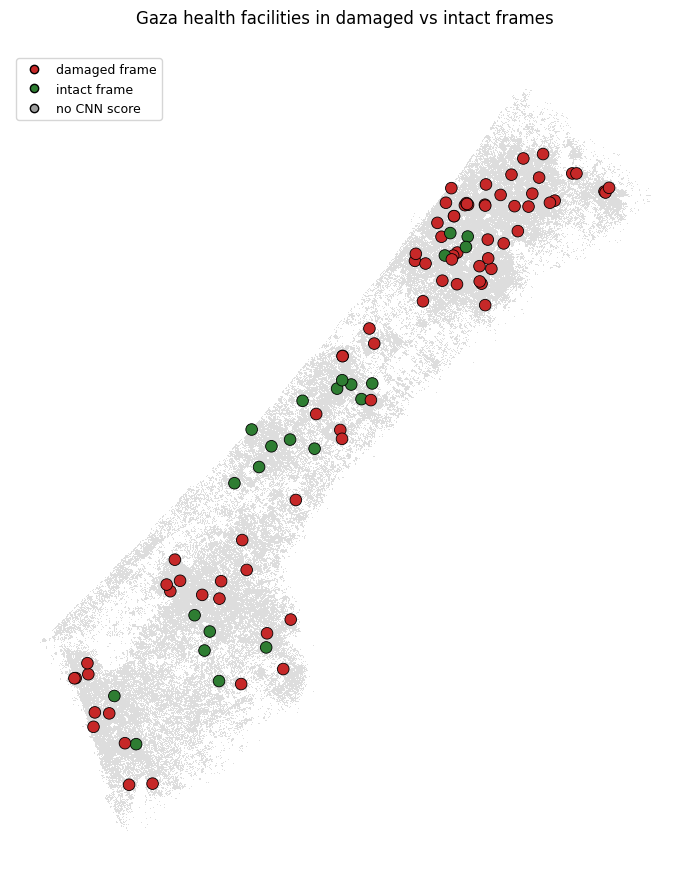

20240906: 78 of 101 facilities in a damaged frame (nearest-footprint rule); 0 without a CNN call


In [81]:
sub = overlay[overlay["date"] == MAP_DATE].reset_index(drop=True) # Filter overlay for map date
lon = fac.to_crs("EPSG:4326").geometry.x.values # Facility longitudes
lat = fac.to_crs("EPSG:4326").geometry.y.values # Facility latitudes

# Assign colors based on damaged status (red for damaged, green for intact, grey for no score)
col = ["#9E9E9E" if pd.isna(v) else ("#C62828" if v else "#2E7D32")
       for v in sub["damaged_nearest"]]

fig, ax = plt.subplots(figsize=(7, 9)) # Create plot figure and axes
ax.scatter(d["lon"], d["lat"], s=0.5, c="#DDDDDD", linewidths=0, rasterized=True) # Plot all footprints
ax.scatter(lon, lat, s=70, c=col, edgecolors="black", linewidths=0.6, zorder=3) # Plot facilities
ax.set_aspect(1 / np.cos(np.radians(np.mean(lat)))) # Set aspect ratio for geographic correctness
ax.set_title(f"{CITY} health facilities in damaged vs intact frames\n") # Set plot title
ax.set_xlabel("longitude"); ax.set_ylabel("latitude") # Set axis labels
ax.legend(handles=[ # Add custom legend
    Line2D([0],[0], marker="o", ls="", mfc="#C62828", mec="k", label="damaged frame"),
    Line2D([0],[0], marker="o", ls="", mfc="#2E7D32", mec="k", label="intact frame"),
    Line2D([0],[0], marker="o", ls="", mfc="#9E9E9E", mec="k", label="no CNN score"),
], loc="upper left", fontsize=9)
ax.set_axis_off() # Turn off axes
plt.tight_layout() # Adjust layout
plt.savefig(os.path.join(OUT["figures"], f"hospital_overlay_{MAP_DATE}.png"),
            dpi=150, bbox_inches="tight") # Save figure
plt.show() # Display figure

n_dest = int(sub["damaged_nearest"].fillna(False).sum()) # Count damaged facilities
n_grey = int(sub["damaged_nearest"].isna().sum()) # Count facilities with no CNN call
print(f"{MAP_DATE}: {n_dest} of {len(sub)} facilities in a damaged frame "
      f"(nearest-footprint rule); {n_grey} without a CNN call")

## 9. Summary of CNN classification for facilities

This section summarizes per-facility damage calls by date, tier, and split band, and tracks changes over time.

### Important Notes:

*   **`train` band optimism:** Model predictions on the training band are not independent and may be optimistic.
*   **Reversals are noise:** Damaged-to-intact transitions are CNN noise, not actual recovery, as scores are independent by date.

The `nearest` rule (`damaged_nearest`) is the primary classification; the `frame` rule (`damaged_frame`) serves as a robustness check.

In [78]:
called = overlay.dropna(subset=["damaged_nearest"]).copy() # Filter for facilities with CNN calls
called["damaged_nearest"] = called["damaged_nearest"].astype(bool) # Convert damaged_nearest to boolean

def _share(g, col):
    """Calculates count, damaged count, and damaged percentage."""
    n = len(g)
    k = int(g[col].fillna(False).astype(bool).sum())
    return pd.Series({"n": n, "damaged": k, "damaged_%": round(k / n * 100, 1) if n else np.nan})

def _ints(df):
    """Converts numeric columns (except percentage) to integers."""
    for col in df.columns:
        name = col[-1] if isinstance(col, tuple) else col
        if not str(name).startswith("damaged_%"):
            df[col] = df[col].astype("Int64")
    return df

# Damaged count per date
print("Facilities in a damaged frame (nearest-footprint rule):\n")
tab = called.groupby("date")[["damaged_nearest"]].apply(lambda g: _share(g, "damaged_nearest"))
print(_ints(tab).to_string())

# Nearest vs frame rule comparison
print("\nNearest rule vs frame rule:\n")
rule = pd.concat({
    "nearest": called.groupby("date")[["damaged_nearest"]].apply(lambda g: _share(g, "damaged_nearest")),
    "frame":   called.dropna(subset=["damaged_frame"]).groupby("date")[["damaged_frame"]].apply(lambda g: _share(g, "damaged_frame")),
}, axis=1)
print(_ints(rule).to_string())
both = called.dropna(subset=["damaged_frame"]) # Facilities with both rules applied
agree = (both["damaged_nearest"] == both["damaged_frame"].astype(bool)).mean() # Agreement rate
print(f"\nnearest and frame rules agree on {agree*100:.0f}% of "
      f"facility-dates ({len(both)} rows)")

# Threshold-free reading of the frame: compare facility frame damage to typical blocks
if "frame_frac_damaged" in called.columns and CITY_PRED_SHARE:
    print("\nFacility frame vs a typical block:\n")
    ff = []
    for dt in DATES:
        g = called[called["date"] == dt].dropna(subset=["frame_frac_damaged"])
        ref = CITY_PRED_SHARE.get(dt)
        if not len(g) or ref is None:
            continue
        ff.append({"date": dt, "n": len(g), "frame_share_median": round(float(g["frame_frac_damaged"].median()), 3),
                   "frame_share_mean": round(float(g["frame_frac_damaged"].mean()), 3),
                   "typical_block": round(ref, 3), "excess": round(float(g["frame_frac_damaged"].mean()) - ref, 3)})
    print(pd.DataFrame(ff).to_string(index=False))
    print("\nexcess > 0: facility blocks are called damaged more than the "
          "typical block.\nNote these blocks are urban and central, which the "
          "city-wide sample is not -\nSection 10 makes the like-for-like "
          "comparison against matched neighbours.")

# Damaged facilities by tier
print("\nFacilities by tier (indicative - small cells):\n")
tier = called.groupby(["tier", "date"])[["damaged_nearest"]].apply(lambda g: _share(g, "damaged_nearest"))
print(_ints(tier).to_string())

# Damaged facilities by split band
print("\nFacilities by split band (train-band calls are optimistic):\n")
band = called.groupby(["split_band", "date"])[["damaged_nearest"]].apply(lambda g: _share(g, "damaged_nearest"))
print(_ints(band).to_string())

# Transitions through time
w = (called.pivot(index="facility_id", columns="date", values="damaged_nearest").reindex(columns=DATES))
w = w.dropna() # Keep facilities with calls at every date

def _path(row):
    """Generates status path (I=intact, D=damaged) across dates."""
    return " -> ".join("D" if v else "I" for v in row)

print(f"\nStatus path across dates (I = intact, D = damaged), "
      f"{len(w)} facilities with a call at every date:\n")
paths = w.apply(_path, axis=1).value_counts() # Count unique status paths
print(paths.to_string())

def _reversal(row):
    """Checks for damaged -> intact reversals."""
    vals = [bool(v) for v in row]
    return any(a and not b for a, b in zip(vals, vals[1:]))

n_rev = int(w.apply(_reversal, axis=1).sum()) # Count reversals
n_new = int(((~w[DATES[0]].astype(bool)) & w[DATES[-1]].astype(bool)).sum()) # Count intact -> damaged transitions
print(f"\n{n_new} facilities go intact -> damaged between "
      f"{DATES[0]} and {DATES[-1]}")
print(f"{n_rev} facilities show a damaged -> intact reversal "
      f"(CNN noise: dates are scored independently)")

summary = {"damaged_by_date": tab, "rule_comparison": rule, "by_tier": tier, "by_band": band, "paths": paths}

Facilities in a damaged frame (nearest-footprint rule):

            n  damaged  damaged_%
date                             
20240503  101       62       61.4
20240706  101       65       64.4
20240906  101       78       77.2

Nearest rule vs frame rule:

         nearest                   frame                  
               n damaged damaged_%     n damaged damaged_%
date                                                      
20240503     101      62      61.4   101      55      54.5
20240706     101      65      64.4   101      64      63.4
20240906     101      78      77.2   101      74      73.3

nearest and frame rules agree on 95% of facility-dates (303 rows)

Facility frame vs a typical block:

    date   n  frame_share_median  frame_share_mean  typical_block  excess
20240503 101               0.840             0.592          0.369   0.223
20240706 101               0.966             0.669          0.490   0.178
20240906 101               1.000             0.756          0.5

### Damaged share over time

This plot shows the percentage of facilities classified as damaged by date, with exact binomial 95% confidence intervals.

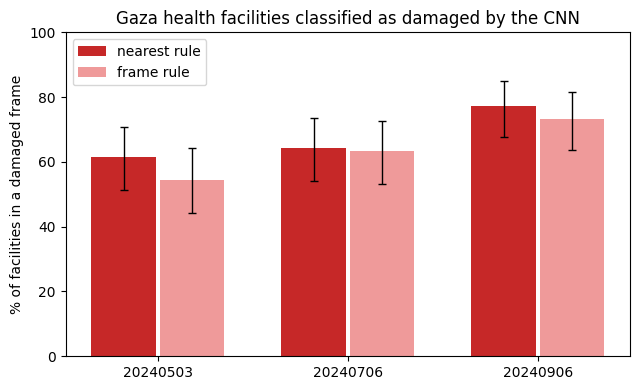

In [79]:
def _clopper_pearson(k, n):
    """Calculates Clopper-Pearson exact interval on a proportion."""
    if n == 0: return np.nan, np.nan
    lo = _beta.ppf(0.025, k, n - k + 1) if k > 0 else 0.0
    hi = _beta.ppf(0.975, k + 1, n - k) if k < n else 1.0
    return lo, hi

fig, ax = plt.subplots(figsize=(6.5, 4)) # Create plot figure and axes
xs = np.arange(len(DATES))
# Plot damaged share for 'nearest' and 'frame' rules with error bars
for off, (name, col) in enumerate([("nearest", "damaged_nearest"), ("frame", "damaged_frame")]):
    ks, ns, los, his = [], [], [], []
    for dt in DATES:
        g = called[(called["date"] == dt)].dropna(subset=[col]) # Filter by date and rule
        k, n = int(g[col].astype(bool).sum()), len(g) # Count damaged and total
        lo, hi = _clopper_pearson(k, n) # Calculate confidence interval
        ks.append(k / n * 100 if n else np.nan); ns.append(n)
        los.append(lo * 100); his.append(hi * 100)
    ks, los, his = map(np.asarray, (ks, los, his))
    ax.bar(xs + (off - 0.5) * 0.36, ks, width=0.34, label=f"{name} rule",
           color="#C62828" if off == 0 else "#EF9A9A") # Plot bars
    ax.errorbar(xs + (off - 0.5) * 0.36, ks, yerr=[ks - los, his - ks],
                fmt="none", ecolor="black", capsize=3, lw=1) # Add error bars
ax.set_xticks(xs, DATES) # Set x-axis ticks and labels
ax.set_ylabel("% of facilities in a damaged frame") # Set y-axis label
ax.set_ylim(0, 100) # Set y-axis limits
ax.set_title(f"{CITY} health facilities classified as damaged by the CNN") # Set plot title
ax.legend() # Display legend
plt.tight_layout() # Adjust layout
plt.savefig(os.path.join(OUT["figures"], "facility_damaged_share_by_date.png"),
            dpi=150, bbox_inches="tight") # Save figure
plt.show() # Display figure

## 10. Example application: Facility damage vs. surroundings

This section demonstrates comparing facility damage rates to their matched surroundings using Cochran-Mantel-Haenszel odds ratios (OR). Footprints within `INNER_M` are 'cases', while those from `INNER_M` to `RING_M` are 'controls', matched by area. An OR > 1 indicates facilities are classified as damaged more often than their neighbors. The analysis uses only CNN output.

In [80]:
# Design parameters for odds ratio analysis
INNER_M  = 60.0  # Footprints within this distance ARE the facility (cases)
RING_M   = 500.0  # Outer edge of the control ring (surroundings)
AREA_CAL = 3.0  # Controls kept within [1/cal, cal] x median case area
N_BOOT   = 400  # Facility-level cluster bootstrap draws for CI

# Load health facilities and prepare for spatial queries
kfac = gpd.read_file(HEALTH_GPKG, layer=HEALTH_LAYER).to_crs(UTM).reset_index(drop=True)
kfac_xy = np.c_[kfac.geometry.x.values, kfac.geometry.y.values] # Facility XY coords
n_fac = len(kfac) # Number of facilities
fdist, fidx = cKDTree(kfac_xy).query(build_xy, k=1) # Footprint -> nearest facility
fp_held = np.ones(n_build, bool) # All footprints considered 'held-out' for this analysis
AREA_COL  = next((c for c in d["table"].columns if "area" in c.lower()), None) # Area column
area_vals = d["table"][AREA_COL].to_numpy(float) if AREA_COL else None # Area values

# Score all footprints within the ring, with caching
CACHE = os.path.join(OUT["predictions"], f"knn_cnn_scores_{CITY}_{int(RING_M)}m_allbands.npz")
need = np.where((fdist <= RING_M) & fp_held)[0] # Footprints within the ring
PRED = None
if os.path.exists(CACHE):
    z = np.load(CACHE) # Load cached scores if available
    if int(z["n_build"]) == n_build and list(z["dates"]) == list(DATES):
        PRED = {dt: z[f"p_{dt}"] for dt in DATES}
        print(f"loaded cached scores: {CACHE}")
if PRED is None: # Score if not cached or cache invalid
    print(f"scoring {len(need):,} footprints x {len(DATES)} dates...")
    PRED = {}
    for dt in DATES:
        arr = np.full(n_build, np.nan)
        for r, p in cnn_scores(dt, need).items(): # Get CNN scores
            arr[int(r)] = p
        PRED[dt] = arr
    np.savez_compressed(CACHE, n_build=n_build, dates=np.array(DATES), **{f"p_{dt}": PRED[dt] for dt in DATES}) # Save scores to cache

# Stratification functions for Cochran-Mantel-Haenszel test
def _strata(thr, dates):
    """Prepares (a,b,c,d) tuples per facility x date for CMH test."""
    out, owner = [], []
    for i in range(n_fac):
        rows = np.where((fidx == i) & (fdist <= RING_M) & fp_held)[0] # Footprints for facility i within ring
        if not len(rows): continue
        case = fdist[rows] <= INNER_M # Footprints within INNER_M are cases
        keep = np.ones(len(rows), bool)
        if area_vals is not None and case.any(): # Apply area matching if applicable
            cm = np.nanmedian(area_vals[rows[case]])
            if np.isfinite(cm) and cm > 0:
                keep = case | ((area_vals[rows] >= cm / AREA_CAL) & (area_vals[rows] <= cm * AREA_CAL))
        for dt in dates:
            p = PRED[dt][rows]
            ok = keep & np.isfinite(p)
            cc, ct = case & ok, (~case) & ok # Cases and controls within valid data
            if not cc.any() or not ct.any(): continue
            pos = p >= thr # Damaged footprints
            out.append((int((pos & cc).sum()), int((~pos & cc).sum()), int((pos & ct).sum()), int((~pos & ct).sum()))) # (a,b,c,d) tuple
            owner.append(i)
    return out, np.asarray(owner)

def _cmh(st):
    """Calculates Cochran-Mantel-Haenszel odds ratio from strata."""
    R = sum(a * dd / (a + b + c + dd) for a, b, c, dd in st if a + b + c + dd)
    S = sum(b * c  / (a + b + c + dd) for a, b, c, dd in st if a + b + c + dd)
    return R / S if R > 0 and S > 0 else np.nan

def _boot_ci(st, owner, seed=293):
    """Performs cluster bootstrap for odds ratio confidence intervals."""
    st = np.asarray(st); groups = [np.where(owner == i)[0] for i in np.unique(owner)]
    rng = np.random.default_rng(seed); vals = []
    for _ in range(N_BOOT):
        pick = rng.integers(0, len(groups), len(groups)) # Resample facility groups
        v = _cmh([tuple(x) for x in st[np.concatenate([groups[k] for k in pick])]])
        if np.isfinite(v): vals.append(v)
    return (np.percentile(vals, 2.5), np.percentile(vals, 97.5)) if len(vals) > N_BOOT // 4 else (np.nan, np.nan)

# Results calculation and display
rows = [] # List to store results
# Iterate through thresholds and dates to calculate OR and other metrics
for label, thr in [("frozen cut", THRESHOLD)]:
    for dt_lab, dates in [("all dates", DATES)] + [(dt, [dt]) for dt in DATES]:
        st, own = _strata(thr, dates) # Get strata and owners
        lo, hi = _boot_ci(st, own) # Calculate bootstrap CI
        n_case = sum(a + b for a, b, _, _ in st) # Total case footprints
        n_ctrl = sum(c + dd for _, _, c, dd in st) # Total control footprints
        p_case = sum(a for a, _, _, _ in st) / n_case if n_case else np.nan # % damaged cases
        p_ctrl = sum(c for _, _, c, _ in st) / n_ctrl if n_ctrl else np.nan # % damaged controls
        rows.append({"threshold": f"{label} ({thr:.2f})", "dates": dt_lab, "strata": len(st),
                     "case_fp": n_case, "ctrl_fp": n_ctrl, "%dmg_case": round(p_case * 100, 1),
                     "%dmg_ctrl": round(p_ctrl * 100, 1), "pp_diff": round((p_case - p_ctrl) * 100, 1),
                     "RR": round(p_case / p_ctrl, 2) if p_ctrl else np.nan, "OR": round(_cmh(st), 2),
                     "CI95": f"[{lo:.2f}, {hi:.2f}]"})
knn = pd.DataFrame(rows) # Create DataFrame of results
print(f"\nFacility vs matched surroundings, CNN calls only "
      f"(ring {RING_M:.0f} m, cases within {INNER_M:.0f} m:")
print("OR > 1 = facilities called damaged MORE than their neighbours; "
      "CI = facility cluster bootstrap.\n"
      "%dmg columns are unadjusted marginals (no stratum matching); pp_diff "
      "and RR are\nderived from them. Quote pp_diff alongside the OR - at "
      "this prevalence the odds\nratio exaggerates the difference in "
      "probability considerably.\n")
print(knn.to_string(index=False))
knn.to_csv(os.path.join(OUT["predictions"], "facility_vs_surroundings_OR.csv"), index=False) # Save results to CSV

loaded cached scores: /content/drive/MyDrive/War-Damage-Detection/sentinel_sar/experiments/exp001_base_cnn_sar/predictions/knn_cnn_scores_Gaza_500m_allbands.npz

Facility vs matched surroundings, CNN calls only (ring 500 m, cases within 60 m:
OR > 1 = facilities called damaged MORE than their neighbours; CI = facility cluster bootstrap.
%dmg columns are unadjusted marginals (no stratum matching); pp_diff and RR are
derived from them. Quote pp_diff alongside the OR - at this prevalence the odds
ratio exaggerates the difference in probability considerably.

        threshold     dates  strata  case_fp  ctrl_fp  %dmg_case  %dmg_ctrl  pp_diff   RR   OR         CI95
frozen cut (0.20) all dates     300     3375   189375       63.8       70.3     -6.4 0.91 0.87 [0.54, 1.49]
frozen cut (0.20)  20240503     100     1125    63125       53.2       62.8     -9.7 0.85 0.73 [0.44, 1.27]
frozen cut (0.20)  20240706     100     1125    63125       64.2       71.3     -7.1 0.90 0.81 [0.43, 1.47]
frozen